# Systems Conference Topic Explorer

Five interactive visualisations of how systems research topics evolved from 2006 to 2025,
based on the DBLP bibliography dump (4,654 papers across 84 conference editions).

**Cell 3** calls the Anthropic API to name clusters — results cached in `data/cluster_labels.json`.

In [1]:
import sys
from pathlib import Path

repo = Path.cwd().parent
if str(repo / "src") not in sys.path:
    sys.path.insert(0, str(repo / "src"))

from dotenv import find_dotenv, load_dotenv
load_dotenv(find_dotenv())

import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

from viz_sys_conferences.viz_data import load_editions
from viz_sys_conferences.viz_plots import (
    papers_over_time,
    keyword_heatmap_matrix,
    topic_trends_embedding,
    conference_similarity,
)

DATA_DIR = repo / "data"
editions = load_editions(DATA_DIR)
print(f"Loaded {len(editions)} editions, {sum(len(e['papers']) for e in editions)} papers")

Loaded 84 editions, 4654 papers


## 1 · Papers over time

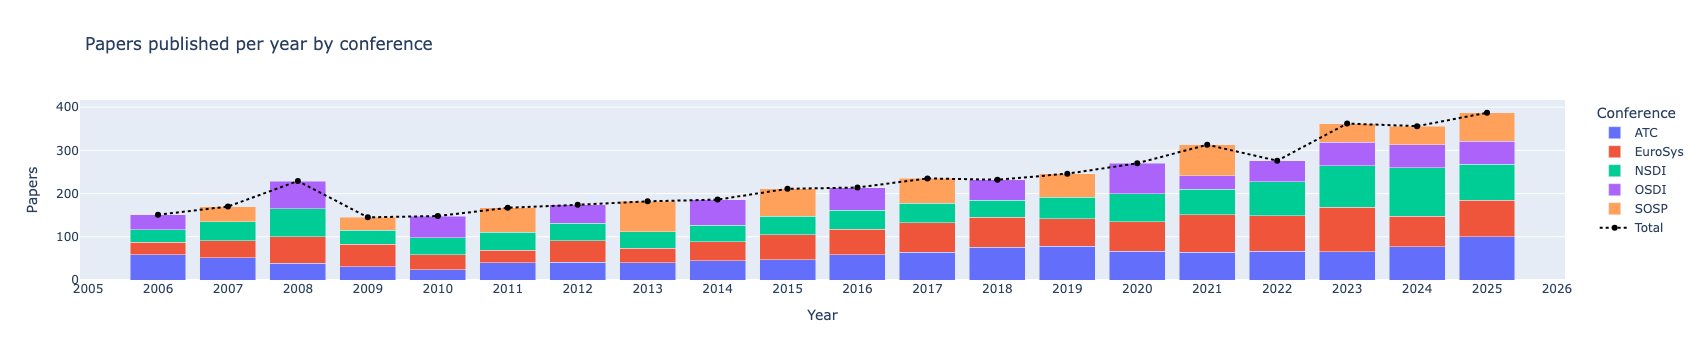

In [2]:
df = papers_over_time(editions)
totals = df.groupby("year", as_index=False)["paper_count"].sum().rename(columns={"paper_count": "total"})

fig = px.bar(
    df, x="year", y="paper_count", color="conference",
    barmode="stack",
    title="Papers published per year by conference",
    labels={"paper_count": "Papers", "year": "Year", "conference": "Conference"},
)
fig.add_scatter(
    x=totals["year"], y=totals["total"],
    mode="lines+markers", name="Total",
    line=dict(color="black", width=2, dash="dot"),
)
fig.update_layout(xaxis=dict(dtick=1), hovermode="x unified")
fig.show()

## 2 · Paper title keyword heatmap

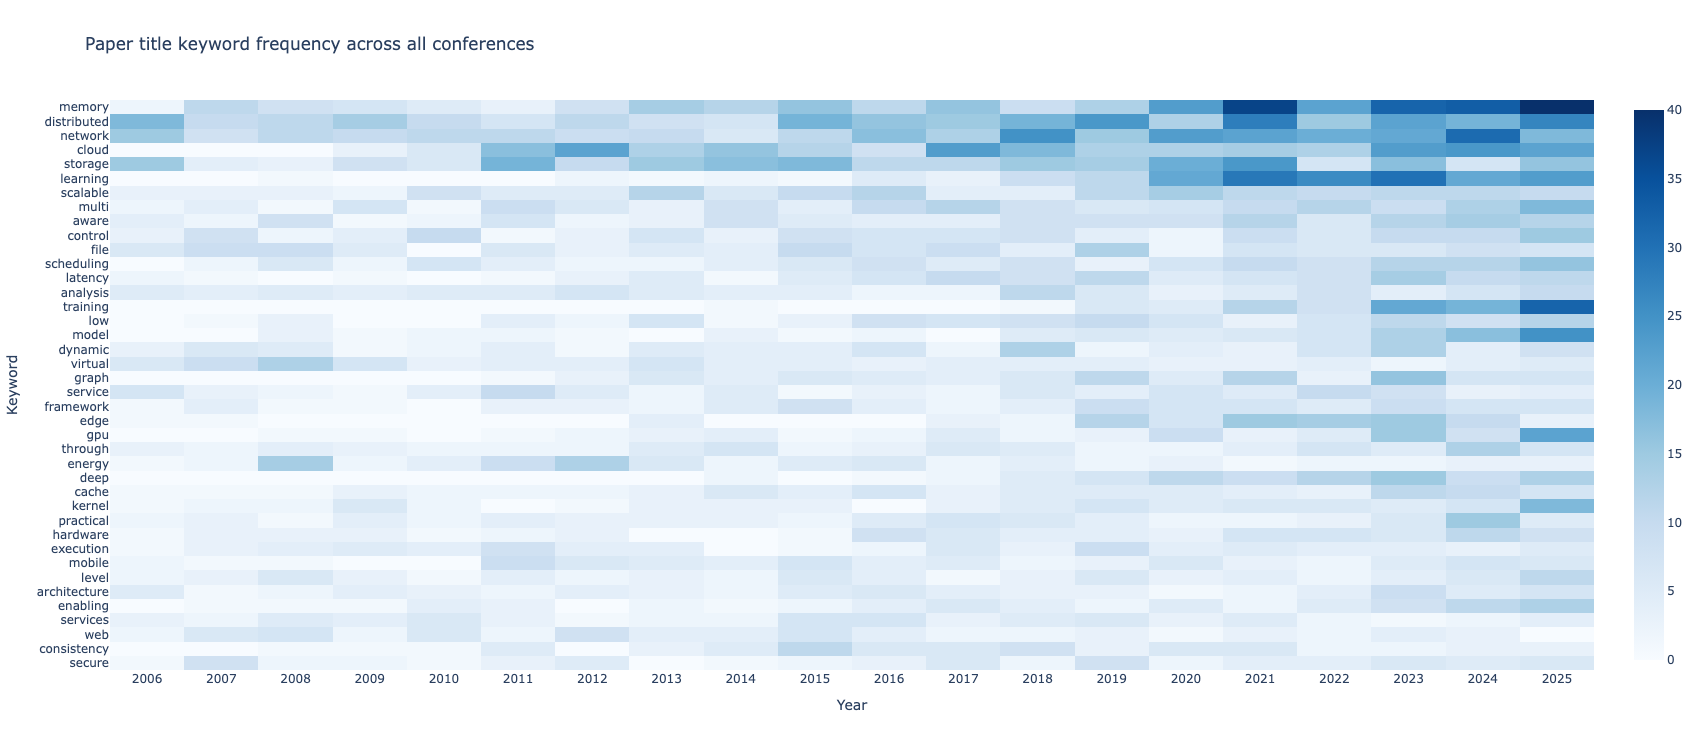

In [3]:
matrix = keyword_heatmap_matrix(editions, top_n=40)

fig = go.Figure(go.Heatmap(
    z=matrix.values,
    x=[str(y) for y in matrix.columns],
    y=matrix.index.tolist(),
    colorscale="Blues",
    hovertemplate="Keyword: %{y}<br>Year: %{x}<br>Count: %{z}<extra></extra>",
))
fig.update_layout(
    title="Paper title keyword frequency across all conferences",
    xaxis_title="Year",
    yaxis_title="Keyword",
    height=750,
    yaxis=dict(autorange="reversed"),
)
fig.show()

## 4 · Topic trend lines

Topics (17): ['Operating systems', 'File and storage systems', 'Distributed systems', 'Cloud computing', 'Mobile and edge systems', 'Secure and reliable systems', 'Systems aspects of big data and machine learning', 'Embedded and real-time systems', 'Virtualization', 'Networking as it relates to operating systems', 'Management and troubleshooting of complex systems', 'Computer architecture', 'Networking', 'Programming languages', 'Analytics', 'Verification', 'Databases']


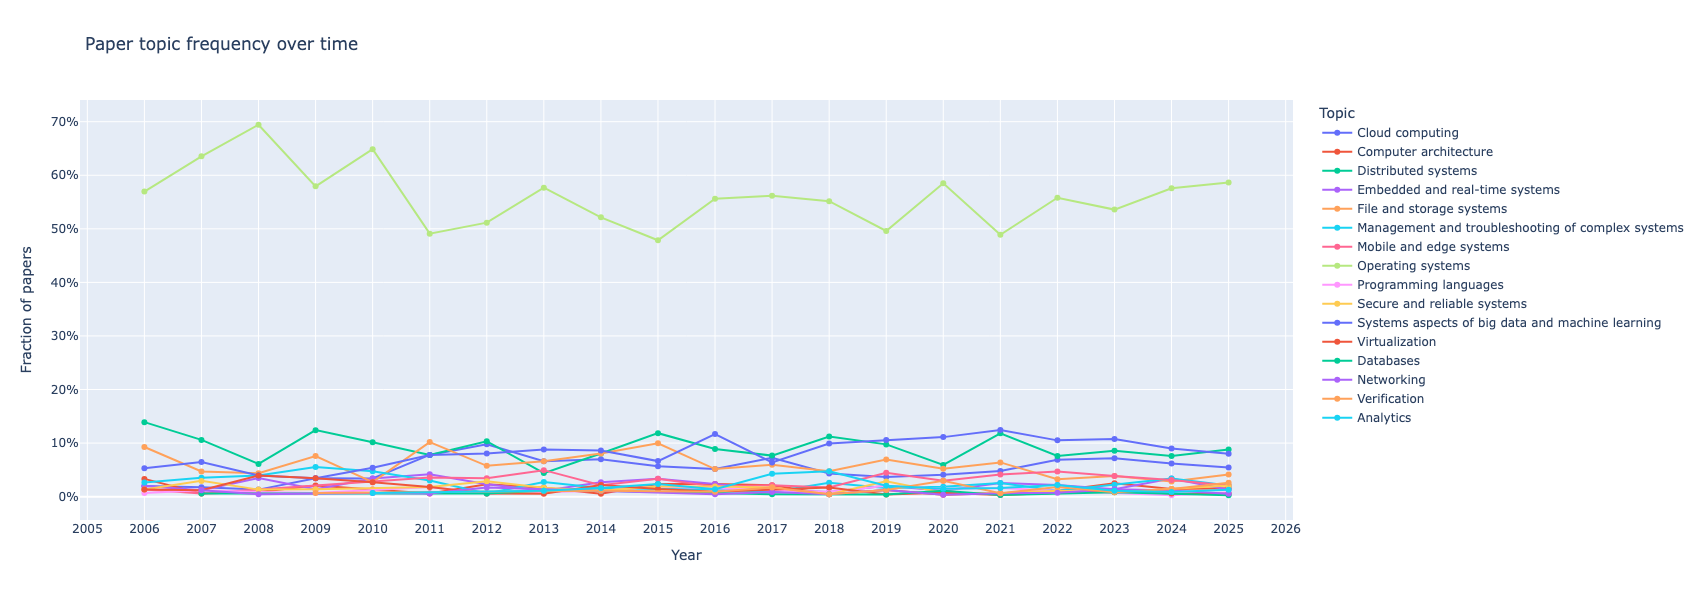

In [4]:
topics = (repo / "sosp26_topics.txt").read_text().strip().splitlines()
print(f"Topics ({len(topics)}):", topics)

trends = topic_trends_embedding(editions, topics)

fig = px.line(
    trends, x="year", y="frequency", color="topic",
    markers=True,
    title="Paper topic frequency over time",
    labels={"frequency": "Fraction of papers", "year": "Year", "topic": "Topic"},
)
fig.update_layout(
    xaxis=dict(dtick=1),
    yaxis=dict(tickformat=".0%"),
    hovermode="x unified",
    height=600,
)
fig.show()

## 4b · Determinism / deterministic in paper titles

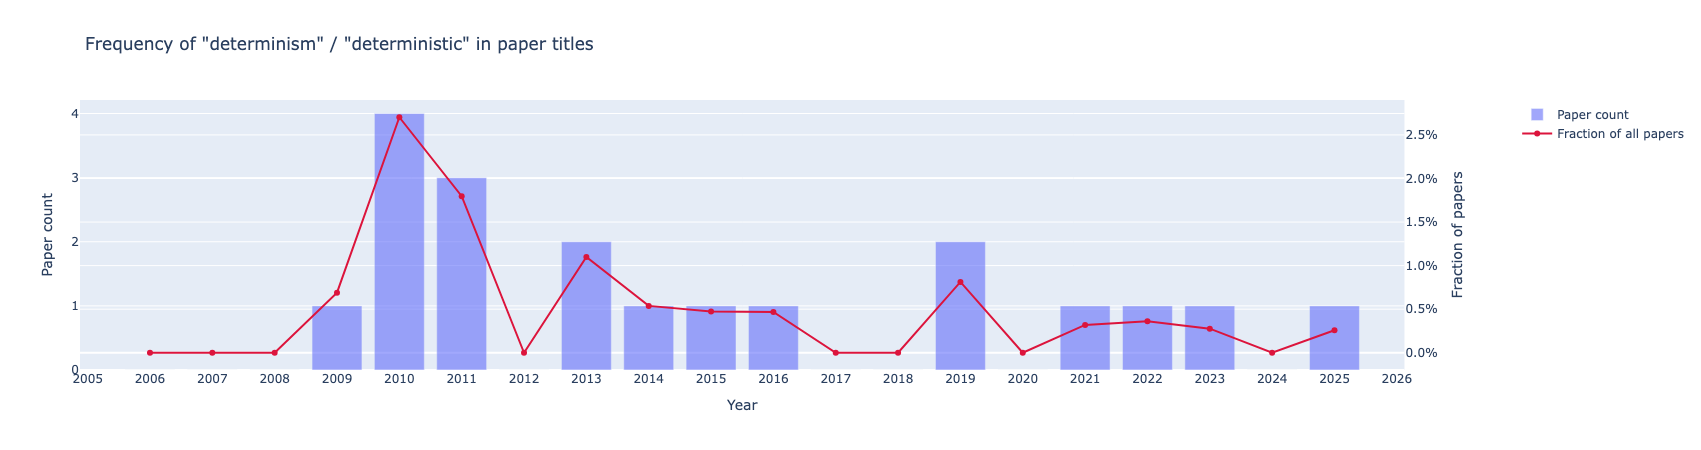

In [5]:
from collections import defaultdict

counts_by_year: dict[int, int] = defaultdict(int)
totals_by_year: dict[int, int] = defaultdict(int)

for e in editions:
    year = e["year"]
    for p in e["papers"]:
        totals_by_year[year] += 1
        if "determinis" in p["title"].lower():
            counts_by_year[year] += 1

years = sorted(totals_by_year)
abs_counts = [counts_by_year[y] for y in years]
rel_freq = [counts_by_year[y] / totals_by_year[y] for y in years]

from plotly.subplots import make_subplots
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_bar(x=years, y=abs_counts, name="Paper count", opacity=0.6)
fig.add_scatter(x=years, y=rel_freq, name="Fraction of all papers",
                mode="lines+markers", line=dict(color="crimson", width=2),
                secondary_y=True)
fig.update_layout(
    title="Frequency of \"determinism\" / \"deterministic\" in paper titles",
    xaxis=dict(dtick=1, title="Year"),
    hovermode="x unified",
    height=450,
)
fig.update_yaxes(title_text="Paper count", secondary_y=False)
fig.update_yaxes(title_text="Fraction of papers", tickformat=".1%", secondary_y=True)
fig.show()

## 5 · Conference topic-overlap

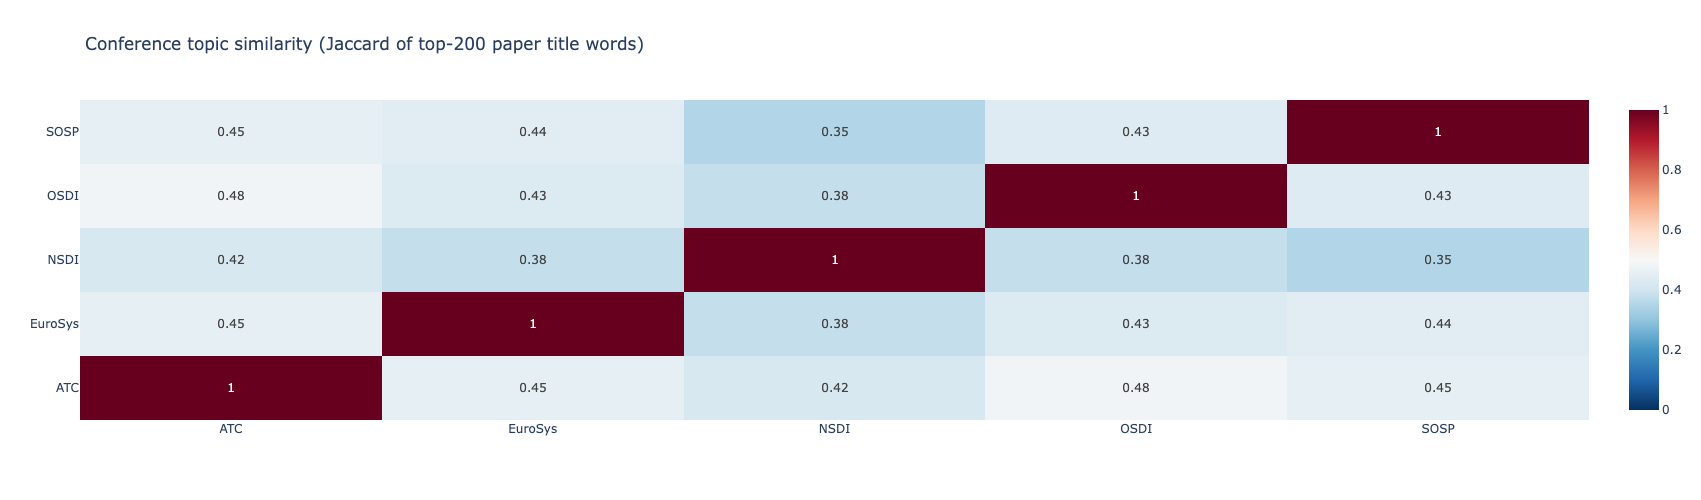

In [6]:
sim = conference_similarity(editions)
confs = sim.index.tolist()

fig = go.Figure(go.Heatmap(
    z=sim.values,
    x=confs,
    y=confs,
    colorscale="RdBu",
    reversescale=True,
    zmin=0, zmax=1,
    text=np.round(sim.values, 2),
    texttemplate="%{text}",
    hovertemplate="%{y} vs %{x}: %{z:.3f}<extra></extra>",
))
fig.update_layout(
    title="Conference topic similarity (Jaccard of top-200 paper title words)",
    height=500,
)
fig.show()